# Electricity Consumption in Spain

## Data Cleaning and Analysis

## Setup

We use Polars because Table A is large. Lazy Parquet scanning allows us to work with the data without loading all 16 million records into memory at once.

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path
import polars as pl

In [2]:
# Project root
PROJECT_ROOT = Path.cwd().parent

# Data directories
MAIN_DATA_DIR = PROJECT_ROOT / "export" / "main_parquet"
METADATA_DIR = PROJECT_ROOT / "export" / "small_parquet"
print("Project root:")
print(PROJECT_ROOT)

print("\nMain data directory:")
print(MAIN_DATA_DIR)

print("\nMetadata directory:")
print(METADATA_DIR)

Project root:
e:\tasks\spain_elec

Main data directory:
e:\tasks\spain_elec\export\main_parquet

Metadata directory:
e:\tasks\spain_elec\export\small_parquet


In [3]:
A_PATH = PROJECT_ROOT / "data" / "a.parquet"

if not A_PATH.exists():
    raise FileNotFoundError(
        f"Could not find Table A at: {A_PATH}\n"
        "Make sure the notebook is inside the EDA folder."
    )

# Keep Table A lazy throughout the main analysis.
A_raw = pl.scan_parquet(str(A_PATH))

print("Table A found:", A_PATH)
print("Table A is being read lazily.")

Table A found: e:\tasks\spain_elec\data\a.parquet
Table A is being read lazily.


## Raw dataset

Before making any assumptions about the variables, I want to see the basic shape of the data: how large it is, what columns exist, and what a few records look like.

In [4]:
raw_schema = A_raw.collect_schema()

A_rows = (
    A_raw
    .select(pl.len())
    .collect()
    .item()
)

print(f"Rows: {A_rows:,}")
print(f"Columns: {len(raw_schema.names())}")

Rows: 16,155,725
Columns: 83


In [5]:
A_raw.head(5).collect()

DIA,H1,ACTIVA_H1,REACTIVA_H1,H2,ACTIVA_H2,REACTIVA_H2,H3,ACTIVA_H3,REACTIVA_H3,H4,ACTIVA_H4,REACTIVA_H4,H5,ACTIVA_H5,REACTIVA_H5,H6,ACTIVA_H6,REACTIVA_H6,H7,ACTIVA_H7,REACTIVA_H7,H8,ACTIVA_H8,REACTIVA_H8,H9,ACTIVA_H9,REACTIVA_H9,H10,ACTIVA_H10,REACTIVA_H10,H11,ACTIVA_H11,REACTIVA_H11,H12,ACTIVA_H12,REACTIVA_H12,…,H16,ACTIVA_H16,REACTIVA_H16,H17,ACTIVA_H17,REACTIVA_H17,H18,ACTIVA_H18,REACTIVA_H18,H19,ACTIVA_H19,REACTIVA_H19,H20,ACTIVA_H20,REACTIVA_H20,H21,ACTIVA_H21,REACTIVA_H21,H22,ACTIVA_H22,REACTIVA_H22,H23,ACTIVA_H23,REACTIVA_H23,H24,ACTIVA_H24,REACTIVA_H24,H25,ACTIVA_H25,REACTIVA_H25,DE_MUNICIP,FECHA_ALTA_STRO,TARGET_TENENCIA_CUPS,IDENTIFICADOR,CNAE,PRODUCTO,MERCADO
str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,str,i64,str,str,str
"""20150624""",1,280,0,2,228,0,3,172,0,4,196,0,5,287,0,6,195,0,7,223,0,8,254,0,9,274,0,10,404,0,11,333,0,12,1106,0,…,16,262,0,17,300,0,18,326,0,19,281,0,20,357,0,21,448,0,22,349,0,23,501,0,24,383,0,25,0,0,"""UBRIQUE""","""Q11989""","""0.127242""",26785,"""T1""","""P1""","""M1"""
"""20150913""",1,142,0,2,61,0,3,67,0,4,64,0,5,64,0,6,70,0,7,126,0,8,101,0,9,40,0,10,179,0,11,131,0,12,169,0,…,16,90,0,17,50,0,18,87,0,19,48,0,20,130,0,21,366,0,22,302,0,23,133,0,24,81,0,25,0,0,"""SANTA COLOMA DE GRAMENET""","""Q31979""","""0.000000""",86782,"""T1""","""P13""","""M2"""
"""20150710""",1,0,0,2,0,0,3,0,0,4,0,0,5,0,0,6,0,0,7,0,0,8,0,0,9,0,0,10,0,0,11,0,0,12,0,0,…,16,0,0,17,0,0,18,0,0,19,0,0,20,0,0,21,0,0,22,0,0,23,0,0,24,0,0,25,0,0,"""VALVERDE""","""Q12010""","""0.000000""",75439,"""T1""","""P14""","""M2"""
"""20150517""",1,186,0,2,129,0,3,176,0,4,123,0,5,183,0,6,200,0,7,185,0,8,170,0,9,161,0,10,409,0,11,399,0,12,351,0,…,16,422,0,17,321,0,18,330,0,19,346,0,20,329,0,21,348,0,22,345,0,23,142,0,24,236,0,25,0,0,"""CAZORLA""","""Q31989""","""0.000000""",43916,"""T1""","""P1""","""M1"""
"""20141108""",1,48,0,2,86,0,3,115,0,4,50,0,5,48,0,6,108,0,7,119,0,8,59,0,9,59,0,10,106,0,11,113,0,12,59,0,…,16,112,0,17,65,0,18,681,0,19,731,0,20,493,0,21,466,0,22,231,0,23,67,0,24,67,0,25,0,0,"""HUELVA""","""Q31989""","""0.011962""",18260,"""T1""","""P1""","""M1"""


## New column names

The original column names are useful for tracing the data back to its source, but English names make the analysis easier to read.

In [6]:
column_mapping = {
    "DIA": "DATE",
    "DE_MUNICIP": "MUNICIPALITY",
    "FECHA_ALTA_STRO": "SUPPLY_REGISTRATION_PERIOD",
    "TARGET_TENENCIA_CUPS": "GAS_DISTRIBUTION_PROBABILITY",
    "IDENTIFICADOR": "CUSTOMER_ID",
    "CNAE": "CUSTOMER_TYPE",
    "PRODUCTO": "ELECTRICITY_PRODUCT",
    "MERCADO": "MARKET",
}

for i in range(1, 26):
    column_mapping[f"H{i}"] = f"TIME_H{i}"
    column_mapping[f"ACTIVA_H{i}"] = f"ACTIVE_H{i}"
    column_mapping[f"REACTIVA_H{i}"] = f"REACTIVE_H{i}"

A = A_raw.rename(column_mapping)

print("Columns after renaming:")
print(A.collect_schema().names())

Columns after renaming:
['DATE', 'TIME_H1', 'ACTIVE_H1', 'REACTIVE_H1', 'TIME_H2', 'ACTIVE_H2', 'REACTIVE_H2', 'TIME_H3', 'ACTIVE_H3', 'REACTIVE_H3', 'TIME_H4', 'ACTIVE_H4', 'REACTIVE_H4', 'TIME_H5', 'ACTIVE_H5', 'REACTIVE_H5', 'TIME_H6', 'ACTIVE_H6', 'REACTIVE_H6', 'TIME_H7', 'ACTIVE_H7', 'REACTIVE_H7', 'TIME_H8', 'ACTIVE_H8', 'REACTIVE_H8', 'TIME_H9', 'ACTIVE_H9', 'REACTIVE_H9', 'TIME_H10', 'ACTIVE_H10', 'REACTIVE_H10', 'TIME_H11', 'ACTIVE_H11', 'REACTIVE_H11', 'TIME_H12', 'ACTIVE_H12', 'REACTIVE_H12', 'TIME_H13', 'ACTIVE_H13', 'REACTIVE_H13', 'TIME_H14', 'ACTIVE_H14', 'REACTIVE_H14', 'TIME_H15', 'ACTIVE_H15', 'REACTIVE_H15', 'TIME_H16', 'ACTIVE_H16', 'REACTIVE_H16', 'TIME_H17', 'ACTIVE_H17', 'REACTIVE_H17', 'TIME_H18', 'ACTIVE_H18', 'REACTIVE_H18', 'TIME_H19', 'ACTIVE_H19', 'REACTIVE_H19', 'TIME_H20', 'ACTIVE_H20', 'REACTIVE_H20', 'TIME_H21', 'ACTIVE_H21', 'REACTIVE_H21', 'TIME_H22', 'ACTIVE_H22', 'REACTIVE_H22', 'TIME_H23', 'ACTIVE_H23', 'REACTIVE_H23', 'TIME_H24', 'ACTIVE_H24', 'R

## Schema Datatypes Fix

In [7]:
schema_table = pl.DataFrame({
    "column": A.collect_schema().names(),
    "dtype": [str(dtype) for dtype in raw_schema.dtypes()],
})

for col, dtype in zip(schema_table["column"], schema_table["dtype"]):
    print(f"{col}: {dtype}")

DATE: String
TIME_H1: Int32
ACTIVE_H1: Int32
REACTIVE_H1: Int32
TIME_H2: Int32
ACTIVE_H2: Int32
REACTIVE_H2: Int32
TIME_H3: Int32
ACTIVE_H3: Int32
REACTIVE_H3: Int32
TIME_H4: Int32
ACTIVE_H4: Int32
REACTIVE_H4: Int32
TIME_H5: Int32
ACTIVE_H5: Int32
REACTIVE_H5: Int32
TIME_H6: Int32
ACTIVE_H6: Int32
REACTIVE_H6: Int32
TIME_H7: Int32
ACTIVE_H7: Int32
REACTIVE_H7: Int32
TIME_H8: Int32
ACTIVE_H8: Int32
REACTIVE_H8: Int32
TIME_H9: Int32
ACTIVE_H9: Int32
REACTIVE_H9: Int32
TIME_H10: Int32
ACTIVE_H10: Int32
REACTIVE_H10: Int32
TIME_H11: Int32
ACTIVE_H11: Int32
REACTIVE_H11: Int32
TIME_H12: Int32
ACTIVE_H12: Int32
REACTIVE_H12: Int32
TIME_H13: Int32
ACTIVE_H13: Int32
REACTIVE_H13: Int32
TIME_H14: Int32
ACTIVE_H14: Int32
REACTIVE_H14: Int32
TIME_H15: Int32
ACTIVE_H15: Int32
REACTIVE_H15: Int32
TIME_H16: Int32
ACTIVE_H16: Int32
REACTIVE_H16: Int32
TIME_H17: Int32
ACTIVE_H17: Int32
REACTIVE_H17: Int32
TIME_H18: Int32
ACTIVE_H18: Int32
REACTIVE_H18: Int32
TIME_H19: Int32
ACTIVE_H19: Int32
REACTIVE

In [8]:
# casting gas distribution probability to float from string 
A = A.with_columns(
    pl.col("GAS_DISTRIBUTION_PROBABILITY").cast(pl.Float32, strict=False)
)
A.collect_schema()["GAS_DISTRIBUTION_PROBABILITY"]

Float32

In [9]:
# casting date column to datetime from string
A = A.with_columns(
    pl.col("DATE")
    .str.strptime(
        pl.Date,
        format="%Y%m%d",
        strict=False
    )
    .alias("DATE")
)

date_range = (
    A.select(
        pl.col("DATE").min().alias("first_date"),
        pl.col("DATE").max().alias("last_date"),
        pl.col("DATE").n_unique().alias("unique_dates"),
        pl.col("DATE").null_count().alias("null_dates"),
    )
    .collect()
)

date_range

first_date,last_date,unique_dates,null_dates
date,date,u32,u32
2013-09-13,2015-10-19,727,0


In [10]:
categorical_cols = [
    "CUSTOMER_TYPE",
    "ELECTRICITY_PRODUCT",
    "MARKET",
]

# casting categorical columns to Categorical type
A = A.with_columns(
    pl.col(col).cast(pl.Categorical, strict=False)
    for col in categorical_cols
)

In [11]:
# replace empty strings in string columns (Municipality and Supply registration period) and categorical with nulls
string_cols = ["MUNICIPALITY", "SUPPLY_REGISTRATION_PERIOD"]

A = A.with_columns([
    pl.when(pl.col(c) == "")
      .then(None)
      .otherwise(pl.col(c))
      .alias(c)
    for c in string_cols+categorical_cols
])

## Time-position variables removal

There are 25 variables named `TIME_H1` to `TIME_H25`. The documentation associated with the dataset describes the original H1–H25 fields as the hour/time positions within the day. These columns do not add any information and could be dropped to reduce columns.

In [12]:
time_cols = [f"TIME_H{i}" for i in range(1, 26)]

time_unique_counts = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in time_cols
    ])
    .collect()
)

time_unique_counts

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2


In [13]:
A.select(time_cols).head(3).collect()

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25


In [14]:
A.select([
    pl.col(c).null_count().alias(c)
    for c in time_cols
]).collect()

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


The H variables are treated as time-position information rather than electricity measurements. The actual energy values are stored separately in the ACTIVE and REACTIVE groups.

In [15]:
# removing time position variables reduces columns from 83 to 58
A = A.drop(time_cols)

## Number of Customers and Municipalities

In [16]:
A.select("MUNICIPALITY").unique().sort("MUNICIPALITY").head().collect()

MUNICIPALITY
str
null
"""A CORUÃ‘A"""
"""ABIA DE LAS TORRES"""
"""ABRERA"""
"""ACEBEDO"""


In [17]:
A.filter(
    pl.col("MUNICIPALITY").is_null()
).collect()

DATE,ACTIVE_H1,REACTIVE_H1,ACTIVE_H2,REACTIVE_H2,ACTIVE_H3,REACTIVE_H3,ACTIVE_H4,REACTIVE_H4,ACTIVE_H5,REACTIVE_H5,ACTIVE_H6,REACTIVE_H6,ACTIVE_H7,REACTIVE_H7,ACTIVE_H8,REACTIVE_H8,ACTIVE_H9,REACTIVE_H9,ACTIVE_H10,REACTIVE_H10,ACTIVE_H11,REACTIVE_H11,ACTIVE_H12,REACTIVE_H12,ACTIVE_H13,REACTIVE_H13,ACTIVE_H14,REACTIVE_H14,ACTIVE_H15,REACTIVE_H15,ACTIVE_H16,REACTIVE_H16,ACTIVE_H17,REACTIVE_H17,ACTIVE_H18,REACTIVE_H18,ACTIVE_H19,REACTIVE_H19,ACTIVE_H20,REACTIVE_H20,ACTIVE_H21,REACTIVE_H21,ACTIVE_H22,REACTIVE_H22,ACTIVE_H23,REACTIVE_H23,ACTIVE_H24,REACTIVE_H24,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,cat,cat,cat
2015-04-06,107,0,64,0,58,0,57,0,54,0,54,1,53,0,185,12,74,9,196,4,79,9,114,3,90,0,48,0,46,0,117,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null,null,0,null,null,null


In [18]:
# customer with id 0 has unknown municipality, customer type, electricity product and market and only comprises of one record from the dataset.
A.filter(
    pl.col("CUSTOMER_ID") == 0
).collect()

DATE,ACTIVE_H1,REACTIVE_H1,ACTIVE_H2,REACTIVE_H2,ACTIVE_H3,REACTIVE_H3,ACTIVE_H4,REACTIVE_H4,ACTIVE_H5,REACTIVE_H5,ACTIVE_H6,REACTIVE_H6,ACTIVE_H7,REACTIVE_H7,ACTIVE_H8,REACTIVE_H8,ACTIVE_H9,REACTIVE_H9,ACTIVE_H10,REACTIVE_H10,ACTIVE_H11,REACTIVE_H11,ACTIVE_H12,REACTIVE_H12,ACTIVE_H13,REACTIVE_H13,ACTIVE_H14,REACTIVE_H14,ACTIVE_H15,REACTIVE_H15,ACTIVE_H16,REACTIVE_H16,ACTIVE_H17,REACTIVE_H17,ACTIVE_H18,REACTIVE_H18,ACTIVE_H19,REACTIVE_H19,ACTIVE_H20,REACTIVE_H20,ACTIVE_H21,REACTIVE_H21,ACTIVE_H22,REACTIVE_H22,ACTIVE_H23,REACTIVE_H23,ACTIVE_H24,REACTIVE_H24,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,cat,cat,cat
2015-04-06,107,0,64,0,58,0,57,0,54,0,54,1,53,0,185,12,74,9,196,4,79,9,114,3,90,0,48,0,46,0,117,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null,null,0,null,null,null


In [19]:
# remove customer with CUSTOMER_ID equal to 0 because there's only one record with that customer ID, and their municipality/location is unkown, proving unuseful for further analysis.
A = A.lazy().remove(pl.col("CUSTOMER_ID") == 0)

In [20]:
customer_geo_overview = (
    A.select([
        pl.col("CUSTOMER_ID").n_unique().alias("unique_customers"),
        pl.col("CUSTOMER_ID").null_count().alias("missing_customer_ids"),
        pl.col("MUNICIPALITY").n_unique().alias("unique_municipalities"),
        pl.col("MUNICIPALITY").null_count().alias("missing_municipalities"),
    ])
    .collect()
)

customer_geo_overview

unique_customers,missing_customer_ids,unique_municipalities,missing_municipalities
u32,u32,u32,u32
99999,0,808,0


## Checking exact duplicates

There are two different concepts:

- an **exact duplicate** has all variables identical; can be easily deduplicated.
- a repeated `CUSTOMER_ID + DATE` may contain different measurements and therefore requires advanced deduplicated methods. In this case we decided to take the row with the max consumption out of its (customer,date) duplicates.

In [21]:
customer_day_counts = (
    A.select(["CUSTOMER_ID", "DATE"])
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg(
        pl.len().alias("records_per_customer_day")
    )
)

customer_day_frequency = (
    customer_day_counts
    .group_by("records_per_customer_day")
    .agg(
        pl.len().alias("customer_days")
    )
    .sort("records_per_customer_day")
    .collect()
)

customer_day_frequency

records_per_customer_day,customer_days
u32,u32
1,15815820
2,167940
3,746
4,444
5,2


In [22]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]
multi_keys = customer_day_counts.filter(pl.col("records_per_customer_day") > 1).select(["CUSTOMER_ID", "DATE"])

diagnostic = (
    A.join(multi_keys, on=["CUSTOMER_ID", "DATE"], how="inner")
    .with_columns(
        pl.sum_horizontal([pl.col(c).is_not_null() for c in active_cols]).alias("hours_populated")
    )
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg([
        pl.len().alias("n_records"),
        pl.col("hours_populated").sum().alias("hours_populated_summed_across_records"),
        pl.col("hours_populated").max().alias("hours_populated_in_fullest_record"),
        pl.col("CUSTOMER_TYPE").n_unique().alias("n_distinct_customer_types"),
        pl.col("MARKET").n_unique().alias("n_distinct_markets"),
        pl.col("ELECTRICITY_PRODUCT").n_unique().alias("n_distinct_products"),
        
        # Calculates how many individual hours contain >1 unique, non-null values 
        pl.sum_horizontal([
            (pl.col(c).n_unique() > 1)
            for c in active_cols
        ]).alias("n_conflicting_hours")
    ])
    .collect()
)

diagnostic.select([
    (pl.col("n_distinct_customer_types") > 1).sum().alias("groups_with_customer_type_change"),
    (pl.col("n_distinct_markets") > 1).sum().alias("groups_with_market_change"),
    (pl.col("n_distinct_products") > 1).sum().alias("groups_with_product_change"),
    ((pl.col("hours_populated_summed_across_records") >= 20) &
     (pl.col("hours_populated_in_fullest_record") < 20)).sum().alias("groups_looking_complementary"),
    (pl.col("n_conflicting_hours") > 0).sum().alias("groups_with_conflicting_energy"),
])

groups_with_customer_type_change,groups_with_market_change,groups_with_product_change,groups_looking_complementary,groups_with_conflicting_energy
u32,u32,u32,u32,u32
0,418,418,0,127216


In [23]:
identical_energy_keys = (
    diagnostic.lazy()
    .filter(pl.col("n_conflicting_hours") == 0)
    .select(["CUSTOMER_ID", "DATE"])
)

identical_energy_records = (
    A.join(identical_energy_keys, on=["CUSTOMER_ID", "DATE"], how="inner")
    .sort(["CUSTOMER_ID", "DATE"])
    .head(4)  
    .collect()
)
identical_energy_records

DATE,ACTIVE_H1,REACTIVE_H1,ACTIVE_H2,REACTIVE_H2,ACTIVE_H3,REACTIVE_H3,ACTIVE_H4,REACTIVE_H4,ACTIVE_H5,REACTIVE_H5,ACTIVE_H6,REACTIVE_H6,ACTIVE_H7,REACTIVE_H7,ACTIVE_H8,REACTIVE_H8,ACTIVE_H9,REACTIVE_H9,ACTIVE_H10,REACTIVE_H10,ACTIVE_H11,REACTIVE_H11,ACTIVE_H12,REACTIVE_H12,ACTIVE_H13,REACTIVE_H13,ACTIVE_H14,REACTIVE_H14,ACTIVE_H15,REACTIVE_H15,ACTIVE_H16,REACTIVE_H16,ACTIVE_H17,REACTIVE_H17,ACTIVE_H18,REACTIVE_H18,ACTIVE_H19,REACTIVE_H19,ACTIVE_H20,REACTIVE_H20,ACTIVE_H21,REACTIVE_H21,ACTIVE_H22,REACTIVE_H22,ACTIVE_H23,REACTIVE_H23,ACTIVE_H24,REACTIVE_H24,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,cat,cat,cat
2015-01-25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""A CORUÃ‘A""","""Q22013""",null,2,"""T2""","""P2""","""M1"""
2015-01-25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""A CORUÃ‘A""","""Q22013""",null,2,"""T2""","""P2""","""M1"""
2015-05-21,72,0,47,0,47,0,48,0,47,0,56,0,65,0,108,0,111,0,101,0,74,0,58,0,103,0,90,0,71,0,74,0,67,0,58,0,102,0,73,0,86,0,50,0,53,0,64,0,0,0,"""SANT BOI DE LLOBREGAT""","""Q21975""",0.6,9,"""T2""","""P1""","""M1"""
2015-05-21,72,0,47,0,47,0,48,0,47,0,56,0,65,0,108,0,111,0,101,0,74,0,58,0,103,0,90,0,71,0,74,0,67,0,58,0,102,0,73,0,86,0,50,0,53,0,64,0,0,0,"""SANT BOI DE LLOBREGAT""","""Q21975""",0.6,9,"""T2""","""P1""","""M1"""


In [24]:
rows_to_deduplicate = (
    A.join(identical_energy_keys, on=["CUSTOMER_ID", "DATE"], how="inner")
    .select(pl.len())
    .collect()
    .item()
)
print(f"Raw duplicated rows with consistent energy: {rows_to_deduplicate}")

Raw duplicated rows with consistent energy: 84717


In [25]:
groups_to_collapse = identical_energy_keys.with_columns(
    pl.lit(True).alias("_collapse")
)

# Keep only one record per collapsing group.
# We use an in-group row index so that "first" is well defined and
# every other row of A is left exactly as it was.
A = (
    A
    .with_columns(
        pl.int_range(pl.len())
          .over(["CUSTOMER_ID", "DATE"])
          .alias("_row_in_group")
    )
    .join(
        groups_to_collapse,
        on=["CUSTOMER_ID", "DATE"],
        how="left"
    )
    .filter(
        pl.col("_collapse").is_null()
        | (pl.col("_row_in_group") == 0)
    )
    .drop(["_row_in_group", "_collapse"])
)

In [26]:
n_collapsing_groups = (
    identical_energy_keys.select(pl.len()).collect().item()
)
rows_removed = rows_to_deduplicate - n_collapsing_groups

print(f"Rows removed:             {rows_removed:,}")
print(f"Rows remaining (lazy):    "
      f"{A.select(pl.len()).collect().item():,}")

# Sanity check: no collapsing group should still contain >1 row.
remaining_dupes = (
    A
    .filter(pl.col("CUSTOMER_ID").is_not_null())
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") > 1)
    .select(pl.len())
    .collect()
    .item()
)
print(f"Groups still with >1 row: {remaining_dupes:,}")

Rows removed:             42,801
Rows remaining (lazy):    16,112,923
Groups still with >1 row: 127,216


In [27]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]

A = (
    A
    .with_columns(
        pl.sum_horizontal([pl.col(c) for c in active_cols]).alias("_temp_total")
    )
    .sort("_temp_total", descending=True)
    .group_by(["CUSTOMER_ID", "DATE"], maintain_order=True)
    .first()
    .drop("_temp_total")
)

remaining = (
    A
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") > 1)
    .select(pl.len())
    .collect()
    .item()
)
print(f"Groups still duplicated: {remaining}")

Groups still duplicated: 0


## Nulls summary

In [28]:
# Missing values across the complete table
all_cols = A.collect_schema().names()

null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in all_cols
    ])
    .collect()
    .transpose(
        include_header=True,
        header_name="column",
        column_names=["null_count"]
    )
    .with_columns(
        (pl.col("null_count") / A_rows * 100).alias("null_percent")
    )
    .sort("null_count", descending=True)
)

null_summary

column,null_count,null_percent
str,u32,f64
"""GAS_DISTRIBUTION_PROBABILITY""",4059057,25.124573
"""SUPPLY_REGISTRATION_PERIOD""",338139,2.092998
"""CUSTOMER_ID""",0,0.0
"""DATE""",0,0.0
"""ACTIVE_H1""",0,0.0
…,…,…
"""REACTIVE_H25""",0,0.0
"""MUNICIPALITY""",0,0.0
"""CUSTOMER_TYPE""",0,0.0


In [29]:
# for faster analysis runtime after deduplication
# One-time cost
A.sink_parquet(
    PROJECT_ROOT / "data" / "A_cleaned.parquet",
    compression="zstd",
    row_group_size=500_000,
)

# All subsequent work reads from the file — fast because it's columnar
A = pl.scan_parquet(PROJECT_ROOT / "data" / "A_cleaned.parquet")

## Active and Reactive electricity consumption columns

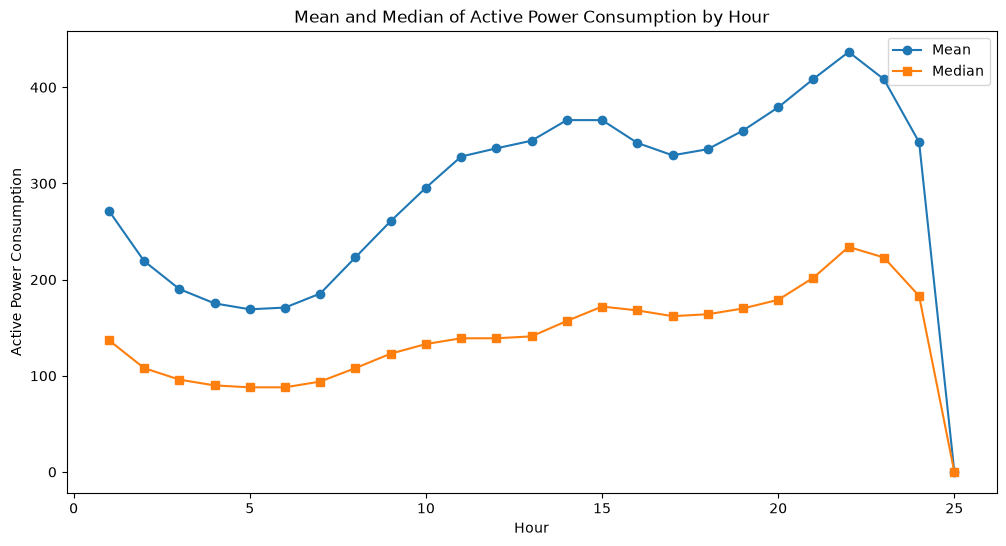

ACTIVE_H1,ACTIVE_H2,ACTIVE_H3,ACTIVE_H4,ACTIVE_H5,ACTIVE_H6,ACTIVE_H7,ACTIVE_H8,ACTIVE_H9,ACTIVE_H10,ACTIVE_H11,ACTIVE_H12,ACTIVE_H13,ACTIVE_H14,ACTIVE_H15,ACTIVE_H16,ACTIVE_H17,ACTIVE_H18,ACTIVE_H19,ACTIVE_H20,ACTIVE_H21,ACTIVE_H22,ACTIVE_H23,ACTIVE_H24,ACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [30]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]

active_stats = []

for c in active_cols:
    row = (
        A.select([
            pl.col(c).count().alias("non_null"),
            pl.col(c).null_count().alias("nulls"),
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )

    active_stats.append({
        "column": c,
        "non_null": row[0],
        "nulls": row[1],
        "minimum": row[2],
        "maximum": row[3],
        "mean": row[4],
        "median": row[5],
    })
    
active_stats_df = pl.DataFrame(active_stats)
time_position = list(range(1, 26))
plt.figure(figsize=(12, 6))
plt.plot(time_position, active_stats_df["mean"], marker='o', label='Mean')
plt.plot(time_position, active_stats_df["median"], marker='s', label='Median')
plt.legend()

plt.title("Mean and Median of Active Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Active Power Consumption")
plt.show()

active_null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in active_cols
    ])
    .collect()
)

active_null_summary

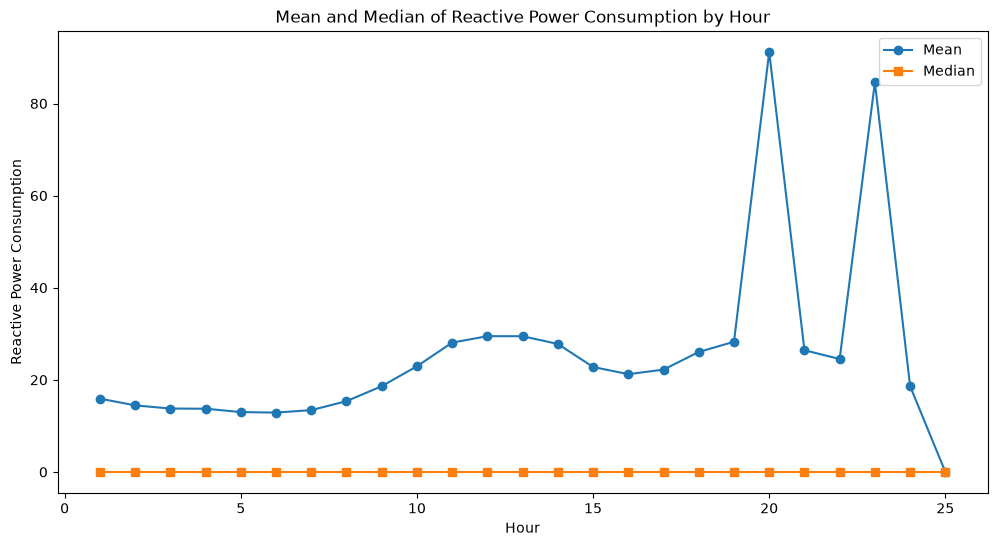

REACTIVE_H1,REACTIVE_H2,REACTIVE_H3,REACTIVE_H4,REACTIVE_H5,REACTIVE_H6,REACTIVE_H7,REACTIVE_H8,REACTIVE_H9,REACTIVE_H10,REACTIVE_H11,REACTIVE_H12,REACTIVE_H13,REACTIVE_H14,REACTIVE_H15,REACTIVE_H16,REACTIVE_H17,REACTIVE_H18,REACTIVE_H19,REACTIVE_H20,REACTIVE_H21,REACTIVE_H22,REACTIVE_H23,REACTIVE_H24,REACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [31]:
reactive_cols = [f"REACTIVE_H{i}" for i in range(1, 26)]
reactive_stats = []

for c in reactive_cols:
    row = (
        A.select([
            pl.col(c).count().alias("non_null"),
            pl.col(c).null_count().alias("nulls"),
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )

    reactive_stats.append({
        "column": c,
        "non_null": row[0],
        "nulls": row[1],
        "minimum": row[2],
        "maximum": row[3],
        "mean": row[4],
        "median": row[5],
    })

reactive_stats_df = pl.DataFrame(reactive_stats)
plt.figure(figsize=(12, 6))
plt.plot(time_position, reactive_stats_df["mean"], marker='o', label='Mean')
plt.plot(time_position, reactive_stats_df["median"], marker='s', label='Median')
plt.legend()

plt.title("Mean and Median of Reactive Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Reactive Power Consumption")
plt.show()
reactive_null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in reactive_cols
    ])
    .collect()
)

reactive_null_summary

## Power Factor Analysis

In [32]:
A = A.with_columns([
    pl.sum_horizontal([pl.col(c).cast(pl.Int64) for c in active_cols]).alias("DAILY_ACTIVE_CONSUMPTION"),
    pl.sum_horizontal([pl.col(c).cast(pl.Int64) for c in reactive_cols]).alias("DAILY_REACTIVE_CONSUMPTION")
])

A = A.with_columns([
    (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2))
    .sqrt()
    .alias("APPARENT_ENERGY"),
    
    pl.when(
        (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2)).sqrt() == 0
    )
    .then(None)
    .otherwise(pl.col("DAILY_ACTIVE_CONSUMPTION") / (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2)).sqrt())
    .alias("POWER_FACTOR")
])

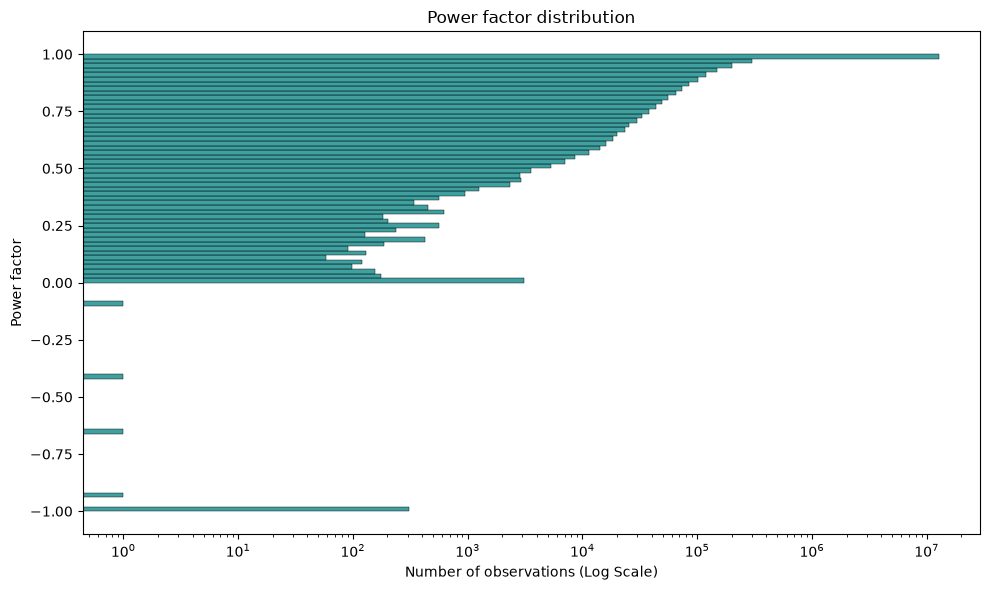

In [33]:
values = (
    A.select("POWER_FACTOR").collect().to_series().to_numpy()
)

plt.figure(figsize=(10, 6))

sns.histplot(y=values, bins=100, color="teal")

plt.xscale("log") 

plt.ylabel("Power factor")
plt.xlabel("Number of observations (Log Scale)")
plt.title("Power factor distribution")

plt.tight_layout()
plt.show()

In [34]:
customer_pf = (
    A
    .group_by("CUSTOMER_ID")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("SUM_P"),
        pl.col("DAILY_REACTIVE_CONSUMPTION").sum().alias("SUM_Q"),
        pl.len().alias("N_DAYS_OBSERVED"),

        # How often does this customer have meaningful load?
        (pl.col("APPARENT_ENERGY") > 0).sum().alias("N_DAYS_WITH_LOAD"),

        # How often does this customer draw reactive power?
        (pl.col("DAILY_REACTIVE_CONSUMPTION") > 0).sum().alias("N_DAYS_WITH_Q"),

        # Fraction of days with PF below 0.95 (only counting loaded days)
        (
            (pl.col("DAILY_ACTIVE_CONSUMPTION") > 0)
            & (pl.col("POWER_FACTOR") < 0.95)
        ).sum().alias("N_DAYS_LOW_PF"),
    ])
    .with_columns([
        (pl.col("SUM_P").pow(2) + pl.col("SUM_Q").pow(2)).sqrt().alias("SUM_S"),
    ])
    .with_columns([
        pl.when(pl.col("SUM_S") == 0)
          .then(None)
          .otherwise(pl.col("SUM_P") / pl.col("SUM_S"))
          .alias("AGG_PF"),

        (pl.col("SUM_Q") / pl.col("SUM_P").abs()).alias("Q_OVER_P"),
        (pl.col("N_DAYS_LOW_PF") / pl.col("N_DAYS_WITH_LOAD")).alias("PCT_DAYS_LOW_PF"),
    ])
)

customer_pf.filter(pl.col("AGG_PF").is_nan() == False).sort("AGG_PF", descending=False).head().collect()

CUSTOMER_ID,SUM_P,SUM_Q,N_DAYS_OBSERVED,N_DAYS_WITH_LOAD,N_DAYS_WITH_Q,N_DAYS_LOW_PF,SUM_S,AGG_PF,Q_OVER_P,PCT_DAYS_LOW_PF
i64,i64,i64,u32,u32,u32,u32,f64,f64,f64,f64
14999,0,4,342,1,1,0,4.0,0.0,inf,0.0
91772,0,16,35,1,1,0,16.0,0.0,inf,0.0
79274,0,6,200,1,1,0,6.0,0.0,inf,0.0
77318,0,1,223,1,1,0,1.0,0.0,inf,0.0
13959,0,128,42,4,4,0,128.0,0.0,inf,0.0


Customers with valid inductive PF: 98,709
Customers with capacitive PF:     0
Customers that are net exporters: 0


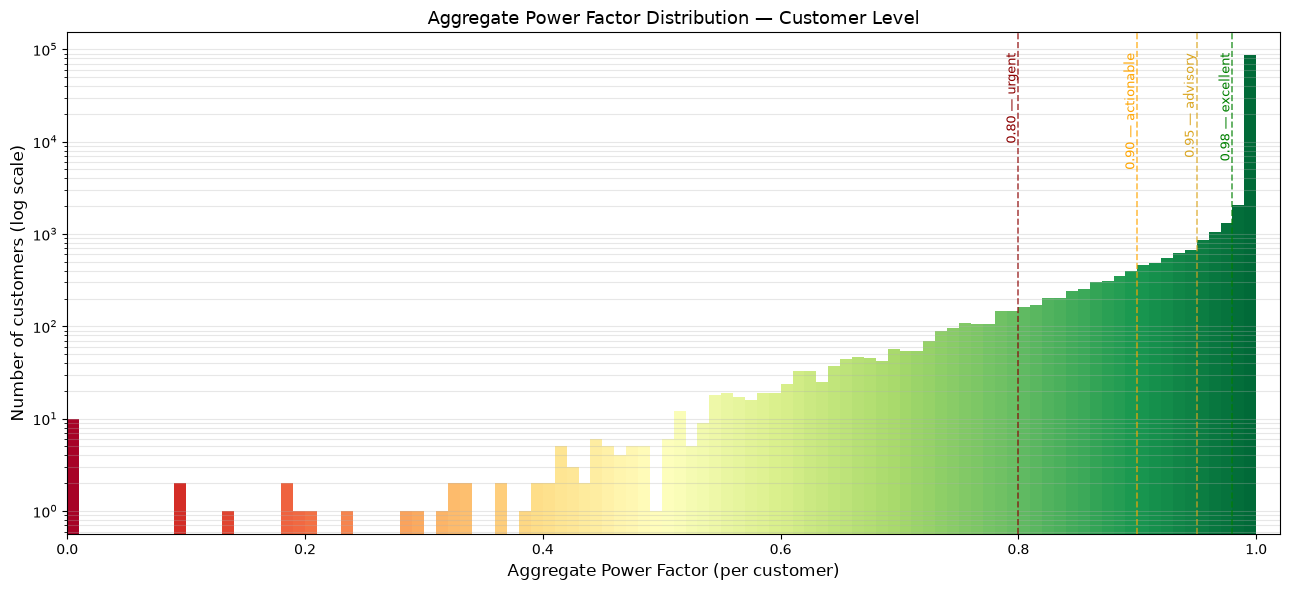

In [40]:
# 1. Materialize customer_pf once — it is currently lazy
customer_pf_df = customer_pf.collect()

# 2. Extract AGG_PF as a NumPy array, dropping nulls
pf_all = (
    customer_pf_df
    .select("AGG_PF")
    .to_series()
    .drop_nulls()
    .to_numpy()
)

# 3. Split into physically distinct populations
pf_inductive = pf_all[(pf_all >= 0) & (pf_all <= 1)]   # normal / inductive load
pf_capacitive = pf_all[pf_all < 0]                     # leading PF

# 4. Count net exporters — this must also be evaluated eagerly
n_prosumers = (
    customer_pf_df
    .select((pl.col("SUM_P") < 0).sum().alias("n"))
    .item()
)

print(f"Customers with valid inductive PF: {len(pf_inductive):,}")
print(f"Customers with capacitive PF:     {len(pf_capacitive):,}")
print(f"Customers that are net exporters: {n_prosumers:,}")

# 5. Build the histogram
bins = np.linspace(0, 1, 101)
counts, edges = np.histogram(pf_inductive, bins=bins)

# 6. Color each bar by its bin midpoint using RdYlGn
cmap = plt.cm.RdYlGn
norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
midpoints = (edges[:-1] + edges[1:]) / 2
bar_colors = cmap(norm(midpoints))

# 7. Plot
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    color=bar_colors,
    edgecolor="none",
    align="edge",
)

ax.set_yscale("log")

for thresh, label, color in [
    (0.80, "0.80 — urgent",     "darkred"),
    (0.90, "0.90 — actionable", "orange"),
    (0.95, "0.95 — advisory",   "goldenrod"),
    (0.98, "0.98 — excellent",  "green"),
]:
    ax.axvline(thresh, color=color, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(
        thresh,
        ax.get_ylim()[1] * 0.6,
        label,
        rotation=90,
        ha="right",
        va="top",
        fontsize=9,
        color=color,
    )

ax.set_xlabel("Aggregate Power Factor (per customer)", fontsize=12)
ax.set_ylabel("Number of customers (log scale)", fontsize=12)
ax.set_title("Aggregate Power Factor Distribution — Customer Level", fontsize=13)
ax.set_xlim(0, 1.02)
ax.grid(axis="y", alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Negative consumption

Negative consumption value at any hour mean that during that time period the customer was selling electricity to the DSO rather than consuming it.

In [41]:
neg_active_cust = (
    A
    .filter(
        pl.any_horizontal([
            pl.col(c) < 0
            for c in active_cols
        ])
    )
    .collect()
    .to_pandas()
)
print(f"Customers with at least one negative active value: {len(neg_active_cust):,}")

Customers with at least one negative active value: 775


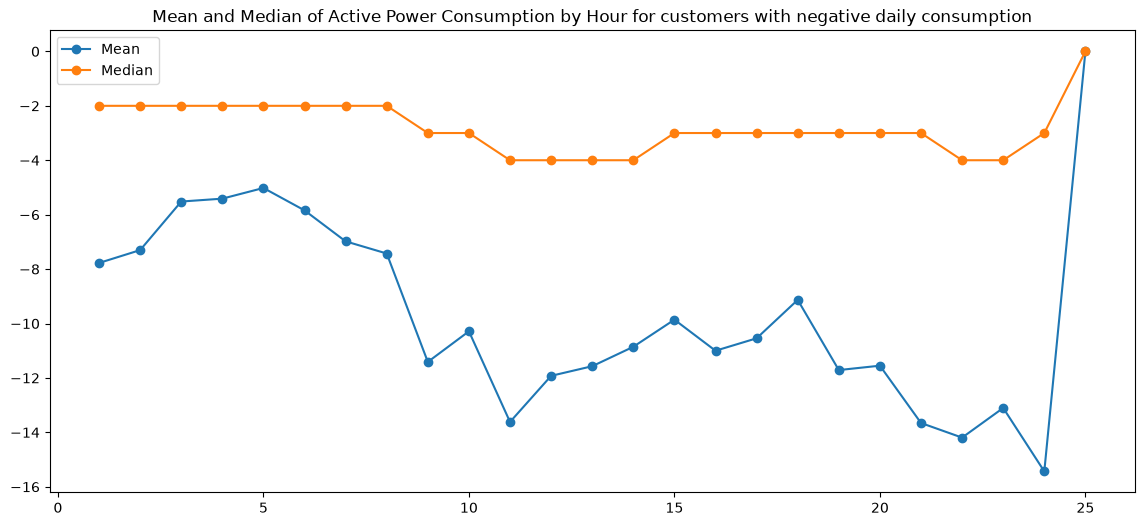

In [42]:
negative_daily_consumption = A.filter(pl.col("DAILY_ACTIVE_CONSUMPTION") < 0).collect().to_pandas()
negative_daily_consumption.shape

neg_active_stats = negative_daily_consumption[active_cols].describe()
plt.figure(figsize=(14, 6))
plt.plot(time_position, neg_active_stats.loc["mean"], marker='o', label='Mean')
plt.plot(time_position, neg_active_stats.loc["50%"], marker='o', label='Median')
plt.legend()
plt.title("Mean and Median of Active Power Consumption by Hour for customers with negative daily consumption")
plt.show()

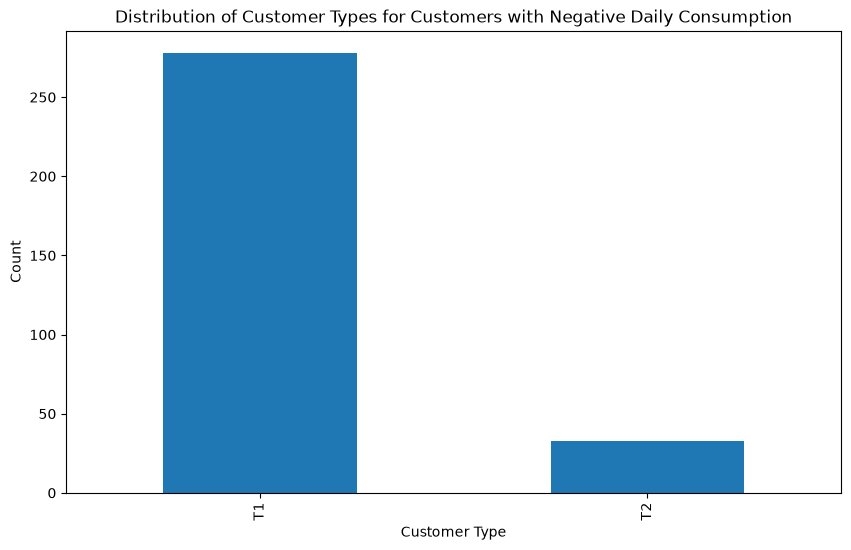

In [43]:
negative_daily_consumption["CUSTOMER_TYPE"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Distribution of Customer Types for Customers with Negative Daily Consumption")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

## Exploring the categorical variables

In [44]:
A = A.with_columns([
        pl.col(c).replace("", None)
        for c in categorical_cols
    ])

categorical_overview = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in categorical_cols
    ])
    .collect()
)

categorical_overview

CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
u32,u32,u32
2,86,2


In [45]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(
        A.select(col)
        .unique()
        .sort(col)
        .head(30)
        .collect()
    )


--- CUSTOMER_TYPE ---
shape: (2, 1)
┌───────────────┐
│ CUSTOMER_TYPE │
│ ---           │
│ cat           │
╞═══════════════╡
│ T1            │
│ T2            │
└───────────────┘

--- ELECTRICITY_PRODUCT ---
shape: (30, 1)
┌─────────────────────┐
│ ELECTRICITY_PRODUCT │
│ ---                 │
│ cat                 │
╞═════════════════════╡
│ P1                  │
│ P106                │
│ P11                 │
│ P110                │
│ P111                │
│ …                   │
│ P28                 │
│ P29                 │
│ P3                  │
│ P30                 │
│ P31                 │
└─────────────────────┘

--- MARKET ---
shape: (2, 1)
┌────────┐
│ MARKET │
│ ---    │
│ cat    │
╞════════╡
│ M1     │
│ M2     │
└────────┘


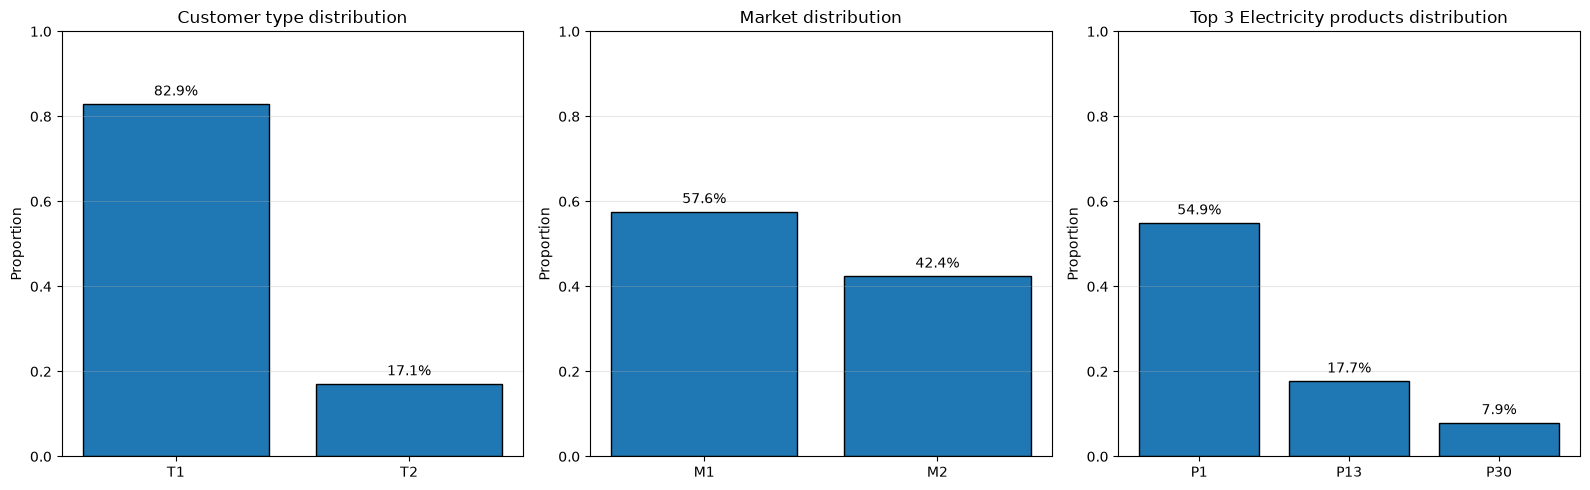

In [46]:
ct = (
    A.select(pl.col("CUSTOMER_TYPE").value_counts(normalize=True))
     .unnest("CUSTOMER_TYPE")
     .collect()
)

mk = (
    A.select(pl.col("MARKET").value_counts(normalize=True))
     .unnest("MARKET")
     .collect()
)

ep = (
    A.select(pl.col("ELECTRICITY_PRODUCT").value_counts(normalize=True))
     .unnest("ELECTRICITY_PRODUCT")
     .sort("proportion", descending=True)
     .collect()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(
    ct["CUSTOMER_TYPE"].to_list(),
    ct["proportion"].to_list(),
    edgecolor="black",
)
axes[0].set_title("Customer type distribution")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

for x, y in zip(ct["CUSTOMER_TYPE"].to_list(), ct["proportion"].to_list()):
    axes[0].text(x, y + 0.02, f"{y:.1%}", ha="center")

axes[1].bar(
    mk["MARKET"].to_list(),
    mk["proportion"].to_list(),
    edgecolor="black",
)
axes[1].set_title("Market distribution")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

for x, y in zip(mk["MARKET"].to_list(), mk["proportion"].to_list()):
    axes[1].text(x, y + 0.02, f"{y:.1%}", ha="center")

axes[2].bar(
    ep["ELECTRICITY_PRODUCT"].to_list()[:3],
    ep["proportion"].to_list()[:3],
    edgecolor="black",
)
axes[2].set_title("Top 3 Electricity products distribution")
axes[2].set_ylabel("Proportion")
axes[2].set_ylim(0, 1)
axes[2].grid(axis="y", alpha=0.3)

for x, y in zip(ep["ELECTRICITY_PRODUCT"].to_list()[:3], ep["proportion"].to_list()[:3]):
    axes[2].text(x, y + 0.02, f"{y:.1%}", ha="center")

plt.tight_layout()
plt.show()

## Supply registration period column

In [47]:
A.select([
    pl.col("SUPPLY_REGISTRATION_PERIOD").is_null().sum().alias("nulls"),
    (pl.col("SUPPLY_REGISTRATION_PERIOD") == "").sum().alias("empties"),
    pl.col("SUPPLY_REGISTRATION_PERIOD").n_unique().alias("distinct"),
]).collect()

nulls,empties,distinct
u32,u32,u32
338139,0,171


In [48]:
A = A.with_columns(
    pl.col("SUPPLY_REGISTRATION_PERIOD").replace("", None)
)

In [49]:
A.select("SUPPLY_REGISTRATION_PERIOD").unique().head().collect()

SUPPLY_REGISTRATION_PERIOD
str
"""Q11983"""
"""Q31979"""
"""Q12001"""
"""Q31963"""
"""Q21968"""


In [50]:
A.select(
    pl.col("SUPPLY_REGISTRATION_PERIOD").str.len_chars().alias("len")
).unique().collect()

len
u32
null
6


In [51]:
A = A.with_columns([
  pl.col("SUPPLY_REGISTRATION_PERIOD")
    .str.slice(1, 1)
    .cast(pl.Int8, strict=False)
    .alias("REG_QUARTER"),

  pl.col("SUPPLY_REGISTRATION_PERIOD")
    .str.slice(2, 5)
    .cast(pl.Int16, strict=False)
    .alias("REG_YEAR"),
])

A.select([
  pl.col("REG_QUARTER").is_null().sum().alias("q_nulls"),
  pl.col("REG_YEAR").is_null().sum().alias("y_nulls"),
]).collect()

q_nulls,y_nulls
u32,u32
338139,338139


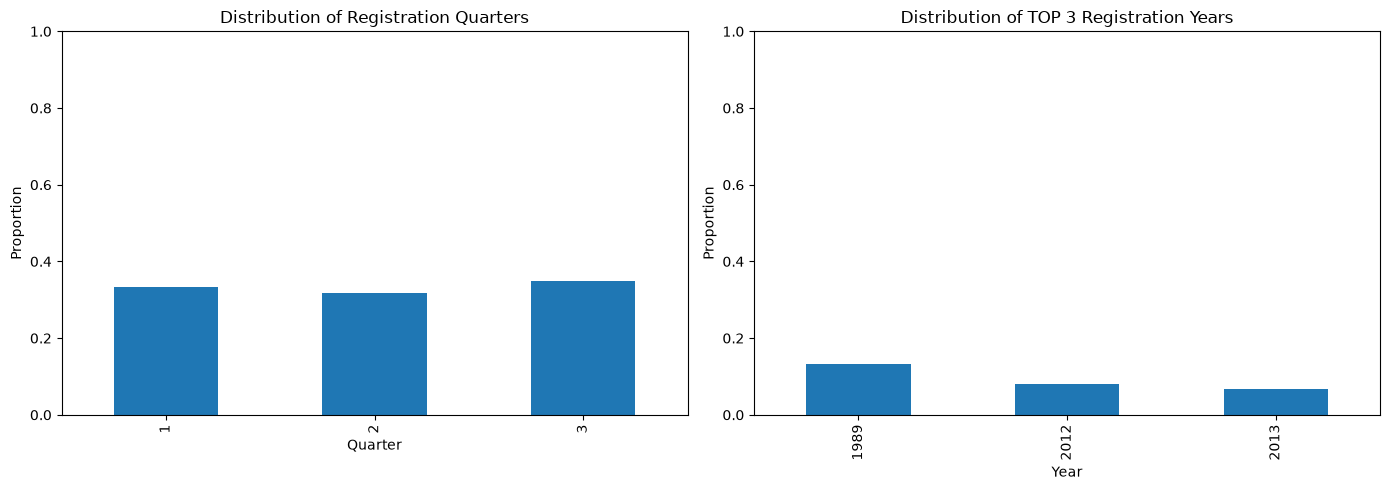

In [52]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

(
    A.filter(pl.col("REG_QUARTER").is_not_null())
    .select(pl.col("REG_QUARTER").value_counts(normalize=True))
    .unnest("REG_QUARTER")
    .sort("REG_QUARTER")
    .collect()
).to_pandas().plot(
    kind="bar",
    x="REG_QUARTER",
    y="proportion",
    legend=False,
    title="Distribution of Registration Quarters",
    xlabel="Quarter",
    ylabel="Proportion",
    ylim=(0, 1),
    ax=ax1, 
)

(
    A.filter(pl.col("REG_YEAR").is_not_null())
    .select(pl.col("REG_YEAR").value_counts(normalize=True))
    .unnest("REG_YEAR")
    .sort("proportion", descending=True)
    .head(3)
    .collect()
).to_pandas().plot(
    kind="bar",
    x="REG_YEAR",
    y="proportion",
    legend=False,
    title="Distribution of TOP 3 Registration Years",
    xlabel="Year",
    ylabel="Proportion",
    ylim=(0, 1),
    ax=ax2,
)

plt.tight_layout()
plt.show()


In [53]:
(
    A.filter(pl.col("REG_YEAR").is_not_null())
    .select(pl.col("REG_YEAR").unique().sort())
    .collect()
)

REG_YEAR
i16
1904
1952
1953
1957
1958
…
2011
2012
2013


## Customer Timeseries data Analysis

In [54]:
summary = (
    A
    .group_by("CUSTOMER_ID")
    .agg([
        pl.col("DATE").min().alias("FIRST_DATE"),
        pl.col("DATE").max().alias("LAST_DATE"),
        pl.col("DATE").n_unique().alias("DISTINCT_DAYS"),
    ])
    .with_columns(
        ((pl.col("LAST_DATE") - pl.col("FIRST_DATE")).dt.total_days() + 1)
            .alias("SPAN_DAYS")
    )
    .with_columns([
        (pl.col("SPAN_DAYS") - pl.col("DISTINCT_DAYS")).alias("MISSING_DAYS"),
        (pl.col("SPAN_DAYS") == pl.col("DISTINCT_DAYS")).alias("IS_CONTINUOUS"),
    ])
)
summary = summary.collect().to_pandas()
print(summary.shape[0])
summary.head()

99999


,CUSTOMER_ID,FIRST_DATE,LAST_DATE,DISTINCT_DAYS,SPAN_DAYS,MISSING_DAYS,IS_CONTINUOUS
0,45895,2014-11-14,2015-09-13,217,304,87,False
1,11156,2014-11-03,2015-09-29,130,331,201,False
2,89676,2014-11-05,2015-10-02,46,332,286,False
3,15607,2014-11-24,2015-10-04,58,315,257,False
4,24393,2014-11-07,2015-10-01,122,329,207,False


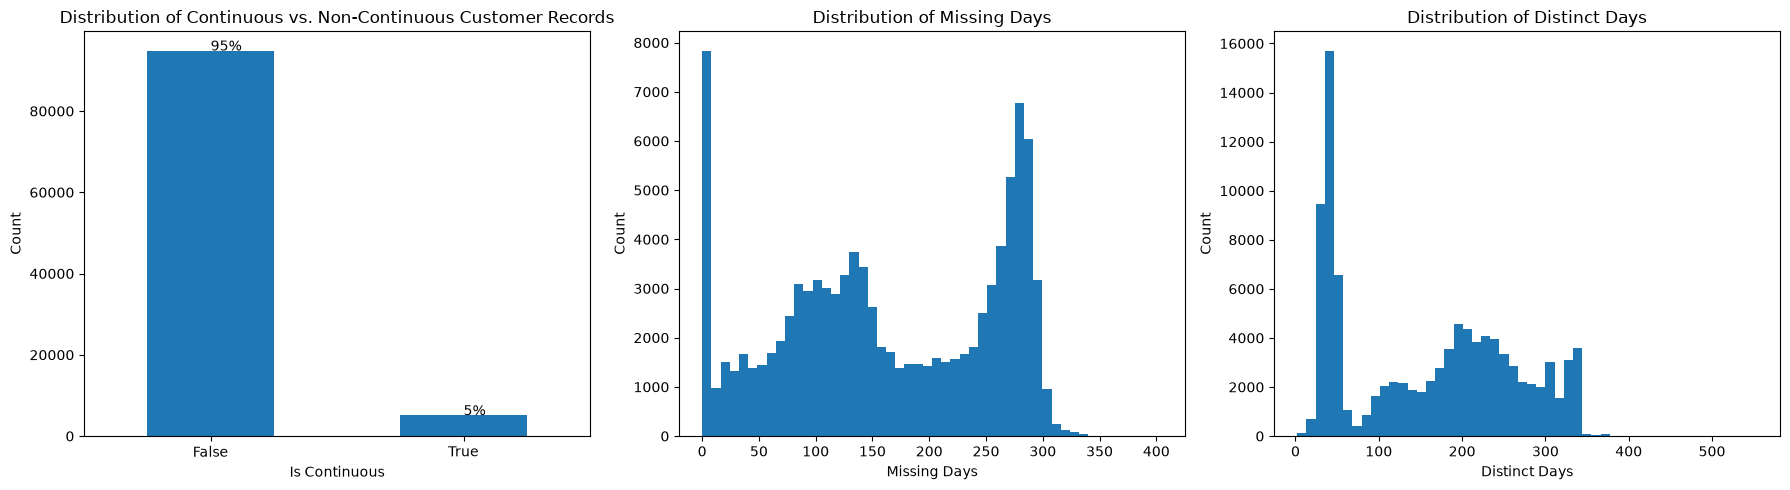

In [55]:
fig, (axes1, axes2, axes3) = plt.subplots(1, 3, figsize=(18, 5))
is_continuous = summary.IS_CONTINUOUS.value_counts()
is_continuous.plot(kind='bar', ax=axes1)
axes1.set_title("Distribution of Continuous vs. Non-Continuous Customer Records")
axes1.set_xlabel("Is Continuous")
axes1.set_ylabel("Count")
axes1.set_xticklabels(axes1.get_xticklabels(), rotation=0)
false_height = is_continuous[False]
true_height = is_continuous[True]
axes1.annotate(f"{is_continuous[False]/99999:.0%}", xy=(0, false_height+2))
axes1.annotate(f"{is_continuous[True]/99999:.0%}", xy=(1, true_height+2))

summary.DISTINCT_DAYS.plot(kind='hist', bins=50, ax=axes3)
axes3.set_title("Distribution of Distinct Days")
axes3.set_xlabel("Distinct Days")
axes3.set_ylabel("Count")

summary.MISSING_DAYS.plot(kind='hist', bins=50, ax=axes2)
axes2.set_title("Distribution of Missing Days")
axes2.set_xlabel("Missing Days")
axes2.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [56]:
runs = (
    A
    .sort(["CUSTOMER_ID", "DATE"])
    .with_columns(
        (pl.col("DATE").diff().dt.total_days() != 1)
            .fill_null(True)
            .cum_sum()
            .over("CUSTOMER_ID")
            .alias("RUN_ID")
    )
    .group_by(["CUSTOMER_ID", "RUN_ID"])
    .agg([
        pl.col("DATE").min().alias("RUN_START"),
        pl.col("DATE").max().alias("RUN_END"),
        pl.len().alias("RUN_LENGTH"),
    ])
)

per_customer_runs = (
    runs
    .group_by("CUSTOMER_ID")
    .agg([
        pl.len().alias("N_RUNS"),
        pl.col("RUN_LENGTH").max().alias("LONGEST_RUN"),
        pl.col("RUN_LENGTH").sum().alias("TOTAL_DAYS"),
    ])
)

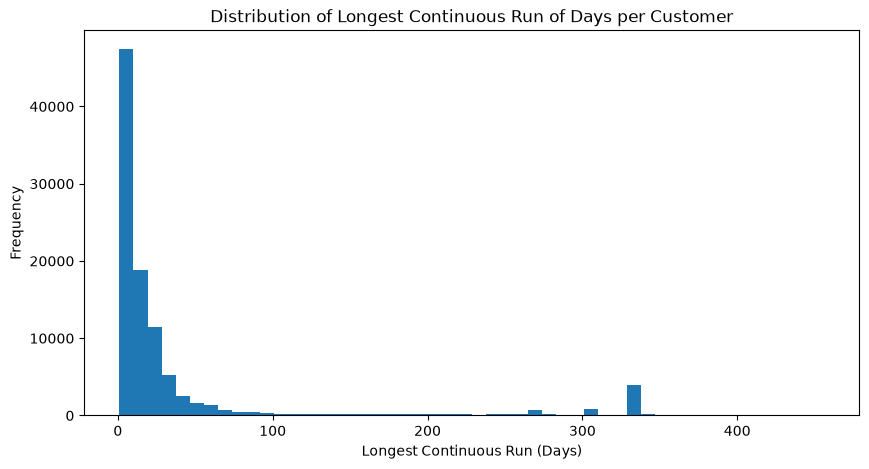

In [57]:
per_customer_runs = per_customer_runs.collect().to_pandas()
per_customer_runs.LONGEST_RUN.plot(kind='hist', bins=50, figsize=(10, 5))
plt.title("Distribution of Longest Continuous Run of Days per Customer")
plt.xlabel("Longest Continuous Run (Days)")
plt.ylabel("Frequency")
plt.show()

In [58]:
per_customer_runs.shape

(99999, 4)

In [59]:
runs = runs.collect().to_pandas()
runs.shape

(4556593, 5)

In [60]:
runs.head()

,CUSTOMER_ID,RUN_ID,RUN_START,RUN_END,RUN_LENGTH
0,46123,26,2015-02-16,2015-02-16,1
1,6329,25,2015-07-02,2015-07-03,2
2,17124,49,2015-06-20,2015-06-20,1
3,7485,13,2015-01-26,2015-01-26,1
4,15916,1,2014-11-09,2014-11-09,1


In [61]:
runs[runs["RUN_LENGTH"] >= 350].shape[0]

71

In [62]:
runs[runs["RUN_LENGTH"] >= 365].shape[0]

56

In [63]:
per_customer_runs[per_customer_runs["LONGEST_RUN"] >= 365].shape[0]

56

`Conclusion`: There is a total of 56 customers with consecutive data of more than or equal to a year (365 days)

## Exporting cleaned data

In [64]:
list(zip(A.collect_schema().names(), A.collect_schema().dtypes()))

[('CUSTOMER_ID', Int64),
 ('DATE', Date),
 ('ACTIVE_H1', Int32),
 ('REACTIVE_H1', Int32),
 ('ACTIVE_H2', Int32),
 ('REACTIVE_H2', Int32),
 ('ACTIVE_H3', Int32),
 ('REACTIVE_H3', Int32),
 ('ACTIVE_H4', Int32),
 ('REACTIVE_H4', Int32),
 ('ACTIVE_H5', Int32),
 ('REACTIVE_H5', Int32),
 ('ACTIVE_H6', Int32),
 ('REACTIVE_H6', Int32),
 ('ACTIVE_H7', Int32),
 ('REACTIVE_H7', Int32),
 ('ACTIVE_H8', Int32),
 ('REACTIVE_H8', Int32),
 ('ACTIVE_H9', Int32),
 ('REACTIVE_H9', Int32),
 ('ACTIVE_H10', Int32),
 ('REACTIVE_H10', Int32),
 ('ACTIVE_H11', Int32),
 ('REACTIVE_H11', Int32),
 ('ACTIVE_H12', Int32),
 ('REACTIVE_H12', Int32),
 ('ACTIVE_H13', Int32),
 ('REACTIVE_H13', Int32),
 ('ACTIVE_H14', Int32),
 ('REACTIVE_H14', Int32),
 ('ACTIVE_H15', Int32),
 ('REACTIVE_H15', Int32),
 ('ACTIVE_H16', Int32),
 ('REACTIVE_H16', Int32),
 ('ACTIVE_H17', Int32),
 ('REACTIVE_H17', Int32),
 ('ACTIVE_H18', Int32),
 ('REACTIVE_H18', Int32),
 ('ACTIVE_H19', Int32),
 ('REACTIVE_H19', Int32),
 ('ACTIVE_H20', Int32),
 (

In [65]:
A.select(pl.len()).collect().item()

15984952

In [ ]:
# (
#     A
#     .sink_parquet(
#         PROJECT_ROOT / "data" / "A_analysis.parquet",
#         compression="zstd",
#         row_group_size=500_000,
#     )
# )